<a href="https://colab.research.google.com/github/DANTALAMEGHANA/Fine--Tuning-BERT-on-Kaggle-Dataset/blob/main/Fine_Tuning_BERT_on_a_Kaggle_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Dataset Selection**

##choose Dataset: IMDB Movie revews from Kaggle

##**GOAL:** Classify movie reviews as Positive or Negative using BERT.

#**1. Data Preprocessing**

##Steps
•Load dataset using pandas

•Remove unnecessary columns

•Handle missing values

•Clean text (lowercase, remove HTML tags, special characters)

•Convert sentiment labels to numeric

In [ ]:
from google.colab import files
files.upload()

In [ ]:
!pip install transformers torch scikit-learn pandas matplotlib seaborn

In [ ]:
import torch
!nvidia-smi

print("CUDA Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

#Import Libraries

In [10]:
import pandas as pd
import numpy as np
import torch

from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import TrainingArguments, Trainer

from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

import seaborn as sns
import matplotlib.pyplot as plt

#Load Dataset

In [11]:
train_df = pd.read_csv("Train.csv")
valid_df = pd.read_csv("Valid.csv")
test_df = pd.read_csv("Test.csv")

print(train_df.head())
print(train_df.columns)

                                                text  label
0  I grew up (b. 1965) watching and loving the Th...      0
1  When I put this movie in my DVD player, and sa...      0
2  Why do people who do not know what a particula...      0
3  Even though I have great interest in Biblical ...      0
4  Im a die hard Dads Army fan and nothing will e...      1
Index(['text', 'label'], dtype='object')


#Preprocessing

In [12]:
train_df = train_df.dropna()
valid_df = valid_df.dropna()
test_df = test_df.dropna()

print(train_df["label"].unique())

[0 1]


#Reduce Dataset

In [17]:
train_df = train_df.sample(10000, random_state=42)
valid_df = valid_df.sample(3000, random_state=42)
test_df = test_df.sample(3000, random_state=42)

print(len(train_df))
print(len(valid_df))
print(len(test_df))

10000
3000
3000


#**2. Data Splitting**
##• The dataset was already provided in Train, Validation, and Test splits, so no additional data splitting was required.

#**3. Tokenization**


In [18]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

def tokenize(texts):
    return tokenizer(
        texts.tolist(),
        padding=True,
        truncation=True,
        max_length=128
    )

train_encodings = tokenize(train_df["text"])
valid_encodings = tokenize(valid_df["text"])
test_encodings = tokenize(test_df["text"])

#**4. Model Building**

##Use AutoModelForSequenceClassification
##Load pre-trained BERT model

In [ ]:
class Dataset(torch.utils.data.Dataset):

    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)


train_dataset = Dataset(train_encodings, train_df["label"].values)
valid_dataset = Dataset(valid_encodings, valid_df["label"].values)
test_dataset = Dataset(test_encodings, test_df["label"].values)




model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)

model

#**5. Fine-Tuning**
##Use AdamW optimizer
##Learning Rate: 2e-5
##Train the model on dataset

In [ ]:
from torch.optim import AdamW

training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=2,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_dir="./logs",
    load_best_model_at_end=True
)

optimizer = AdamW(model.parameters(), lr=2e-5)

def compute_metrics(pred):

    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        preds,
        average='binary'
    )

    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=valid_dataset,
    processing_class=tokenizer,
    compute_metrics=compute_metrics,
    optimizers=(optimizer, None)
)

trainer.train()

#**6. Model Evaluation**

##Evaluate using:
•Accuracy

•Precision

•Recall

•F1 Score

•Confusion Matrix


In [32]:
results = trainer.evaluate(test_dataset)
print(results)

{'eval_loss': 0.33773863315582275, 'eval_accuracy': 0.8703333333333333, 'eval_precision': 0.853486884197057, 'eval_recall': 0.892904953145917, 'eval_f1': 0.8727510631337912, 'eval_runtime': 25.8099, 'eval_samples_per_second': 116.234, 'eval_steps_per_second': 7.284, 'epoch': 2.0}


#**Generate Predictions**

#Accuracy, Precision, Recall, F1

In [33]:
preds = trainer.predict(test_dataset)

y_pred = preds.predictions.argmax(-1)
y_true = preds.label_ids

accuracy = accuracy_score(y_true, y_pred)
precision = precision_recall_fscore_support(y_true, y_pred, average='binary')[0]
recall = precision_recall_fscore_support(y_true, y_pred, average='binary')[1]
f1 = precision_recall_fscore_support(y_true, y_pred, average='binary')[2]

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)

Accuracy: 0.8703333333333333
Precision: 0.853486884197057
Recall: 0.892904953145917
F1: 0.8727510631337912


#Confusion Matrix

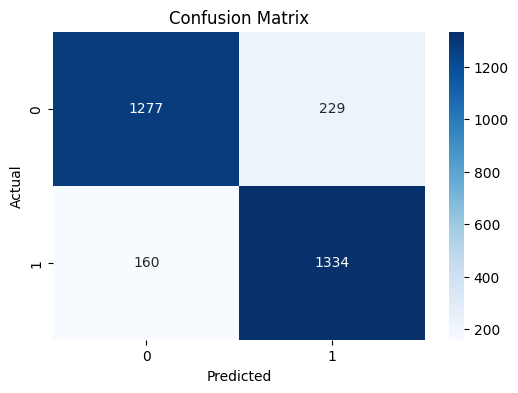

In [34]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

# **Pipeline Flow**

##Raw Data → Preprocessing → Tokenization → Model Training → Evaluation → Comparison
